**Cell 1 — Imports and configuration**

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

TICKERS = {
    "Bayer":      {"file": "BAYN_DE_log_returns.csv", "color": "black", "out": "BAYN_DE_std_log_returns.csv"},
    "BMW":        {"file": "BMW_DE_log_returns.csv",  "color": "red", "out": "BMW_DE_std_log_returns.csv"},
    "Siemens":    {"file": "SIE_DE_log_returns.csv", "color": "blue", "out": "SIE_DE_std_log_returns.csv"},
    "Volkswagen": {"file": "VOW_DE_log_returns.csv", "color": "green", "out": "VOW_DE_std_log_returns.csv"},
}

**Cell 2 — Load, standardize, and export**

In [8]:
def load_close_series(filename):
    path = os.path.join(DATA_DIR, filename)
    s = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")["Close"]
    s.index = pd.to_datetime(s.index, format="%d.%m.%Y")
    return s

def standardize(s):
    return (s - s.mean()) / s.std()

returns = {}
for name, cfg in TICKERS.items():
    raw = load_close_series(cfg["file"])
    std = standardize(raw)
    std.to_csv(os.path.join(DATA_DIR, cfg["out"]), header=True)
    returns[name] = std

**Cell 3 — Plot each series separately**

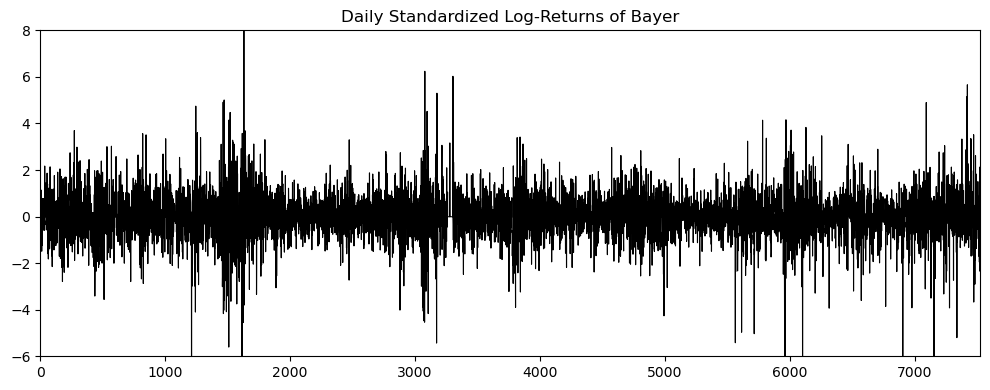

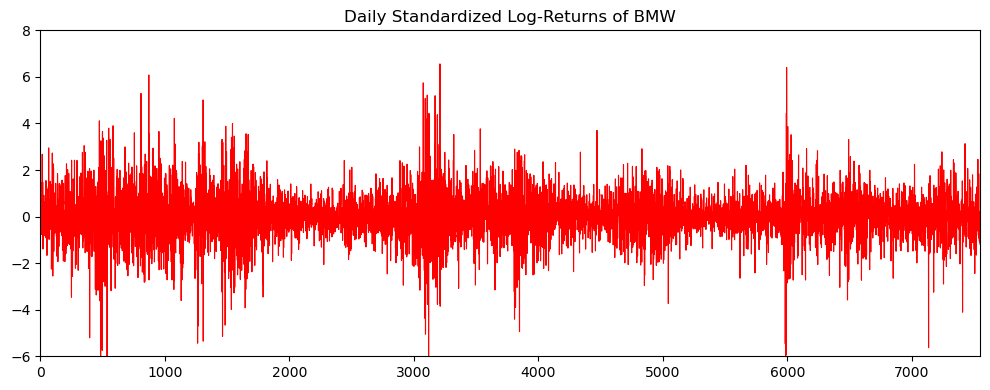

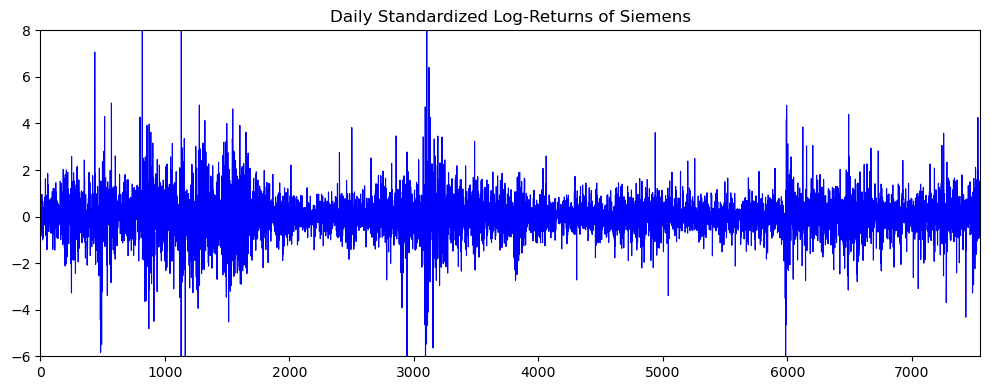

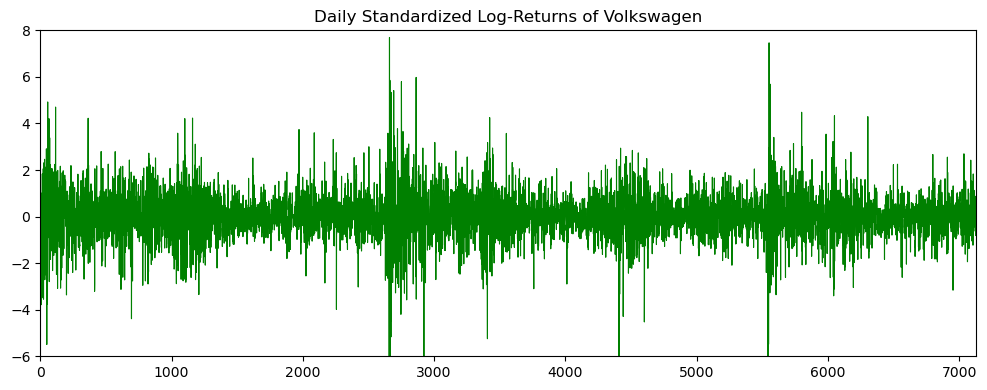

In [11]:
for i, (name, series) in enumerate(returns.items(), start=1):
    color = TICKERS[name]["color"]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(series.values, color=color, linewidth=0.8)
    ax.set_ylim(-6, 8)
    ax.set_xlim(0, len(series) - 1)
    ax.set_title(f"Daily Standardized Log-Returns of {name}")
    ax.grid(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"std_log_returns_{i}.png"),
                dpi=200, transparent=True, bbox_inches="tight")
    plt.show()